# KCE081BCT004 - Predicting Energy Consumption
**Dataset:** PJM AEP Hourly Energy Dataset
**Target:** PJME_MW (Megawatts)

## Step 1 - Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import zscore

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib

print('All libraries imported')

All libraries imported


## Step 2 - Load Dataset

In [2]:
# Load the csv file
df = pd.read_csv("PJM(AEP)_energy_dataset.csv")

# Strip extra spaces from column names
df.columns = df.columns.str.strip()

# Convert Datetime column to proper datetime format
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Fix dirty data - remove any non-numeric characters from PJME_MW
df['PJME_MW'] = pd.to_numeric(df['PJME_MW'].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

# Sort by date
df.sort_values('Datetime', inplace=True)
df.reset_index(drop=True, inplace=True)

print('Shape:', df.shape)
print('Date Range:', df['Datetime'].min(), 'to', df['Datetime'].max())
df.head()

Shape: (145366, 2)
Date Range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00


,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


## Step 3 - Data Cleaning

In [3]:
# Check data types
print('Data Types:')
print(df.dtypes)

Data Types:
Datetime    datetime64[us]
PJME_MW            float64
dtype: object


In [4]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
Datetime    0
PJME_MW     0
dtype: int64


In [3]:
# Handle missing values using forward fill
if df['PJME_MW'].isnull().sum() > 0:
    df['PJME_MW'].fillna(method='ffill', inplace=True)
    df['PJME_MW'].fillna(method='bfill', inplace=True)
    print('Missing values filled')
else:
    print('No missing values found')

No missing values found


In [6]:
# Check for duplicate rows
print('Number of duplicate rows:', df.duplicated().sum())

Number of duplicate rows: 0


In [4]:
# Drop duplicates if any
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print('Shape after removing duplicates:', df.shape)

Shape after removing duplicates: (145366, 2)


In [8]:
# Check unique values
print('Unique Datetime values:', df['Datetime'].nunique())
print('Unique PJME_MW values:', df['PJME_MW'].nunique())

Unique Datetime values: 145362
Unique PJME_MW values: 28441


In [9]:
# Basic statistics
df.describe()

,Datetime,PJME_MW
count,145366,145366.000000
mean,2010-04-18 03:25:25.999202,32080.222831
min,2002-01-01 01:00:00,14544.000000
25%,2006-02-23 14:15:00,27573.000000
50%,2010-04-18 04:30:00,31421.000000
75%,2014-06-10 18:45:00,35650.000000
max,2018-08-03 00:00:00,62009.000000
std,NaN,6464.012166


## Step 4 - Overall Consumption Analysis

In [10]:
# Compute mean, median, min, max
print('Mean   :', round(df['PJME_MW'].mean(), 2), 'MW')
print('Median :', round(df['PJME_MW'].median(), 2), 'MW')
print('Min    :', round(df['PJME_MW'].min(), 2), 'MW')
print('Max    :', round(df['PJME_MW'].max(), 2), 'MW')
print('Std Dev:', round(df['PJME_MW'].std(), 2), 'MW')

Mean   : 32080.22 MW
Median : 31421.0 MW
Min    : 14544.0 MW
Max    : 62009.0 MW
Std Dev: 6464.01 MW


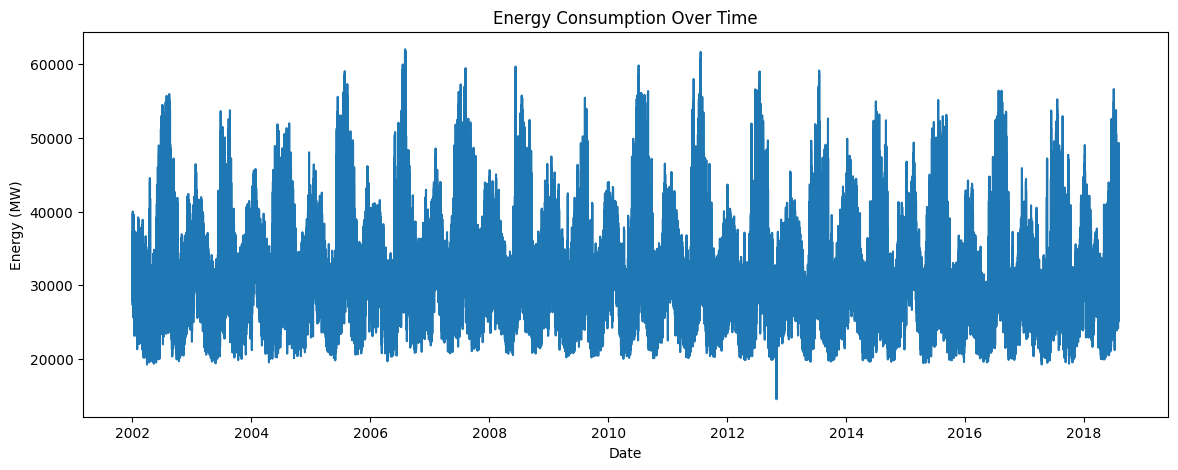

In [11]:
# Plot energy consumption over time
plt.figure(figsize=(14, 5))
plt.plot(df['Datetime'], df['PJME_MW'])
plt.title('Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Energy (MW)')
plt.show()

## Step 5 - Time-Based Trend Analysis

In [12]:
# Extract time components from Datetime
df['hour']        = df['Datetime'].dt.hour
df['day']         = df['Datetime'].dt.day
df['month']       = df['Datetime'].dt.month
df['year']        = df['Datetime'].dt.year
df['day_of_week'] = df['Datetime'].dt.dayofweek
df['quarter']     = df['Datetime'].dt.quarter

print('Time features added')
df[['Datetime', 'hour', 'day', 'month', 'year', 'day_of_week']].head()

Time features added


,Datetime,hour,day,month,year,day_of_week
0,2002-01-01 01:00:00,1,1,1,2002,1
1,2002-01-01 02:00:00,2,1,1,2002,1
2,2002-01-01 03:00:00,3,1,1,2002,1
3,2002-01-01 04:00:00,4,1,1,2002,1
4,2002-01-01 05:00:00,5,1,1,2002,1


In [13]:
# Average energy consumption per year
yearly_avg = df.groupby('year')['PJME_MW'].mean()
print(yearly_avg)

year
2002    31565.617106
2003    31698.758621
2004    32270.434867
2005    33310.478648
2006    32409.269696
2007    33613.468600
2008    32929.593373
2009    31851.533683
2010    33101.172662
2011    32368.308518
2012    31440.107265
2013    31706.525120
2014    31496.406963
2015    31709.394178
2016    31337.833106
2017    30650.911644
2018    31782.598715
Name: PJME_MW, dtype: float64


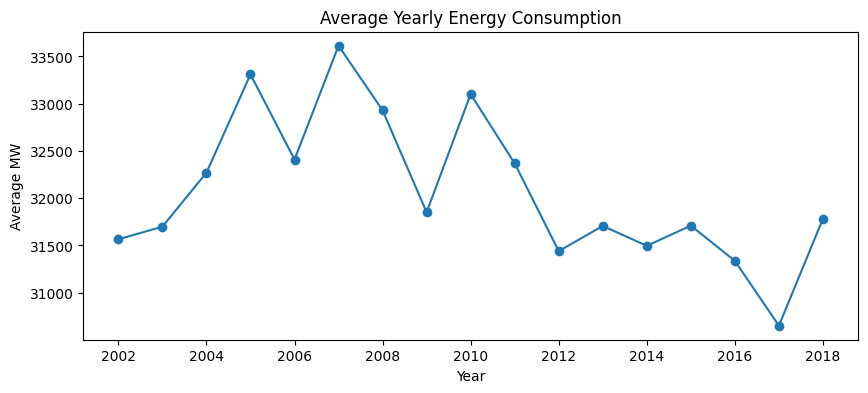

In [14]:
# Plot yearly average
plt.figure(figsize=(10, 4))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.title('Average Yearly Energy Consumption')
plt.xlabel('Year')
plt.ylabel('Average MW')
plt.show()

In [15]:
# Average energy consumption per month
monthly_avg = df.groupby('month')['PJME_MW'].mean()
print(monthly_avg)

month
1     34343.246462
2     33434.972049
3     30514.903609
4     27863.339354
5     28695.362113
6     33811.799183
7     37881.972881
8     36595.959675
9     31484.054688
10    28119.228675
11    29328.733872
12    32676.247669
Name: PJME_MW, dtype: float64


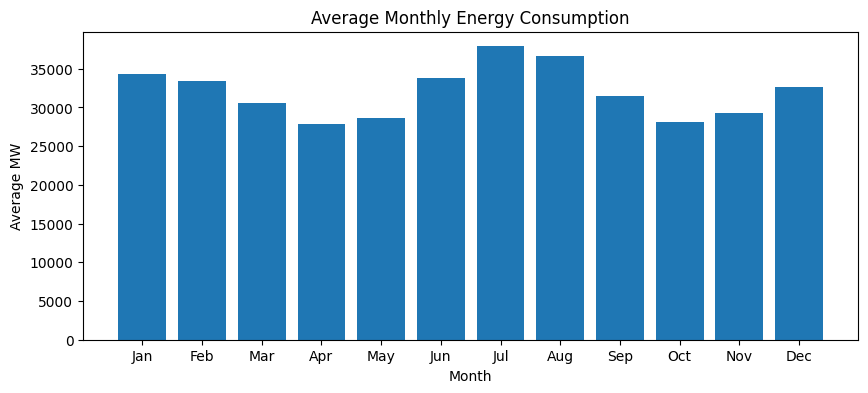

In [16]:
# Plot monthly average
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10, 4))
plt.bar(month_names, monthly_avg.values)
plt.title('Average Monthly Energy Consumption')
plt.xlabel('Month')
plt.ylabel('Average MW')
plt.show()

In [17]:
# Average energy consumption per day of week
daily_avg = df.groupby('day_of_week')['PJME_MW'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print(daily_avg)

day_of_week
0    32672.028420
1    33272.265746
2    33261.497498
3    33085.857727
4    32688.097688
5    30162.880588
6    29411.869930
Name: PJME_MW, dtype: float64


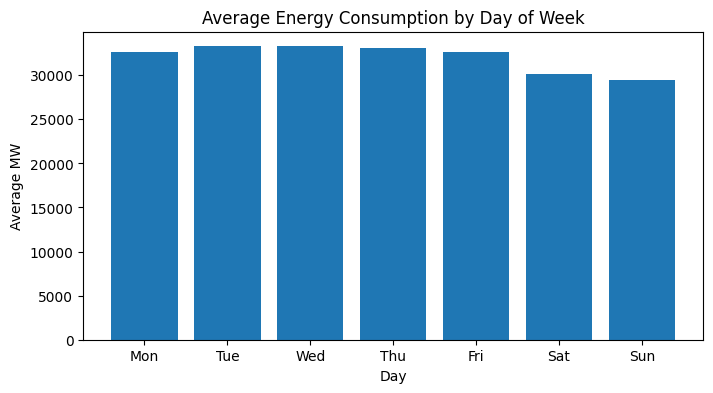

In [18]:
# Plot daily average
plt.figure(figsize=(8, 4))
plt.bar(day_names, daily_avg.values)
plt.title('Average Energy Consumption by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average MW')
plt.show()

## Step 6 - Seasonal and Cyclical Patterns

<Figure size 1200x500 with 0 Axes>

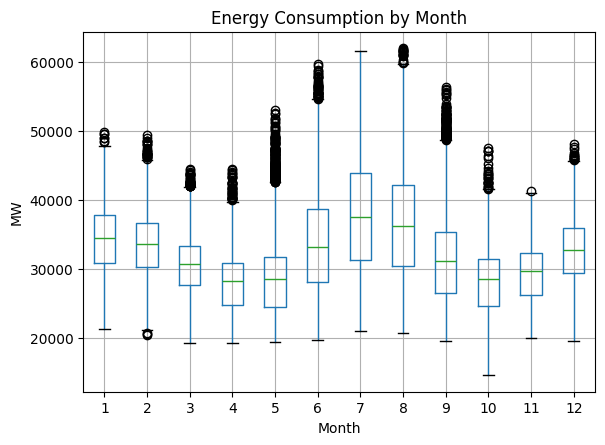

In [19]:
# Boxplot by month to see seasonal pattern
plt.figure(figsize=(12, 5))
df.boxplot(column='PJME_MW', by='month')
plt.title('Energy Consumption by Month')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('MW')
plt.show()

<Figure size 1000x500 with 0 Axes>

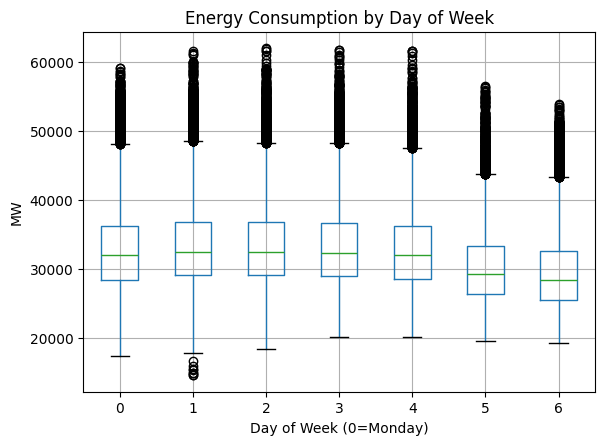

In [20]:
# Boxplot by day of week - weekday vs weekend
plt.figure(figsize=(10, 5))
df.boxplot(column='PJME_MW', by='day_of_week')
plt.title('Energy Consumption by Day of Week')
plt.suptitle('')
plt.xlabel('Day of Week (0=Monday)')
plt.ylabel('MW')
plt.show()

In [21]:
# Average energy per hour - to find peak hours
hourly_avg = df.groupby('hour')['PJME_MW'].mean()
print('Peak Hour:', hourly_avg.idxmax(), ':00')
print('Low  Hour:', hourly_avg.idxmin(), ':00')

Peak Hour: 19 :00
Low  Hour: 4 :00


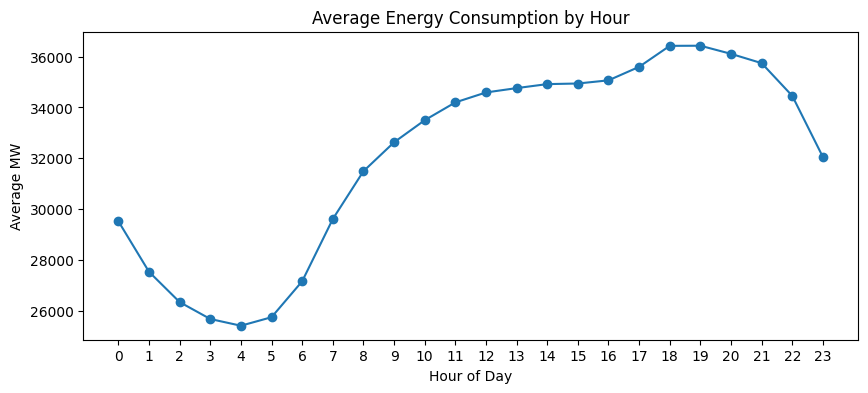

In [22]:
# Plot hourly average
plt.figure(figsize=(10, 4))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title('Average Energy Consumption by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average MW')
plt.xticks(range(0, 24))
plt.show()

## Step 7 - Time Component Analysis

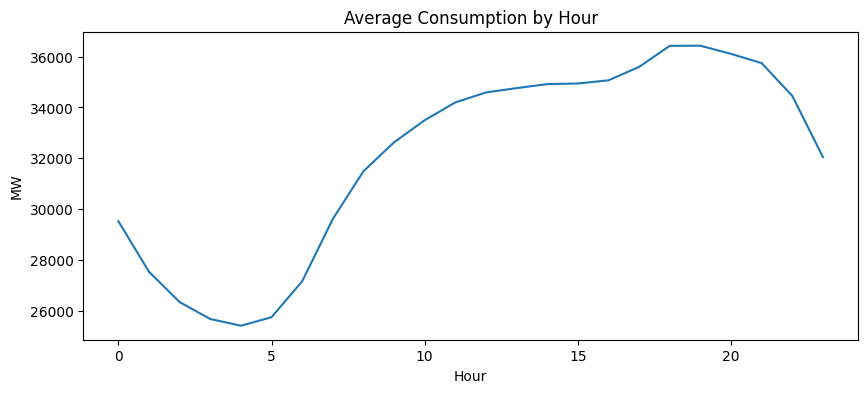

In [23]:
# Average consumption by hour
avg_hour = df.groupby('hour')['PJME_MW'].mean()
plt.figure(figsize=(10, 4))
plt.plot(avg_hour.index, avg_hour.values)
plt.title('Average Consumption by Hour')
plt.xlabel('Hour')
plt.ylabel('MW')
plt.show()

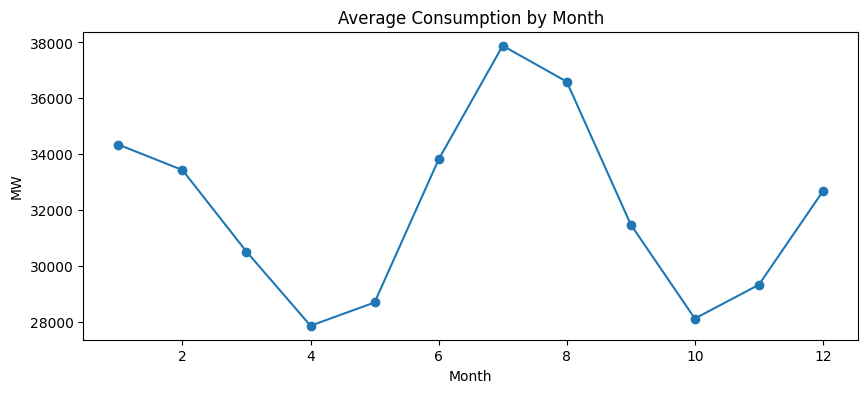

In [24]:
# Average consumption by month
avg_month = df.groupby('month')['PJME_MW'].mean()
plt.figure(figsize=(10, 4))
plt.plot(avg_month.index, avg_month.values, marker='o')
plt.title('Average Consumption by Month')
plt.xlabel('Month')
plt.ylabel('MW')
plt.show()

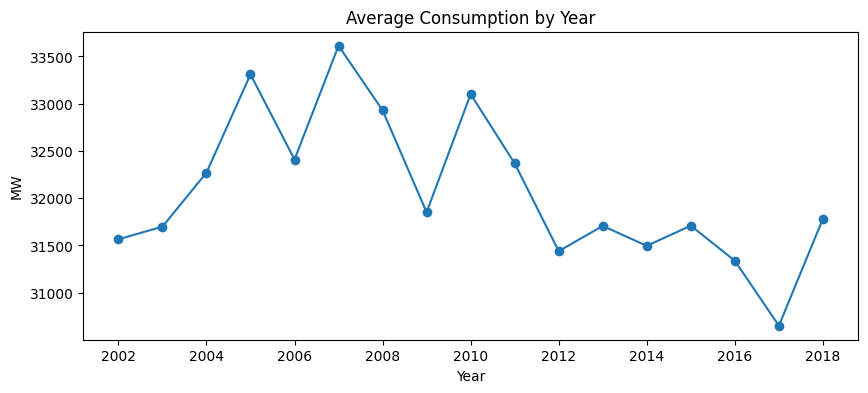

In [25]:
# Average consumption by year
avg_year = df.groupby('year')['PJME_MW'].mean()
plt.figure(figsize=(10, 4))
plt.plot(avg_year.index, avg_year.values, marker='o')
plt.title('Average Consumption by Year')
plt.xlabel('Year')
plt.ylabel('MW')
plt.show()

In [26]:
# Identify peak and low consumption periods
print('Peak hour        :', df.groupby('hour')['PJME_MW'].mean().idxmax(), ':00')
print('Low hour         :', df.groupby('hour')['PJME_MW'].mean().idxmin(), ':00')
print('High consumption month:', df.groupby('month')['PJME_MW'].mean().idxmax())
print('Low  consumption month:', df.groupby('month')['PJME_MW'].mean().idxmin())
print('Low  consumption day  :', df.groupby('day_of_week')['PJME_MW'].mean().idxmin(), '(0=Mon)')

Peak hour        : 19 :00
Low hour         : 4 :00
High consumption month: 7
Low  consumption month: 4
Low  consumption day  : 6 (0=Mon)


## Step 8 - Distribution Analysis

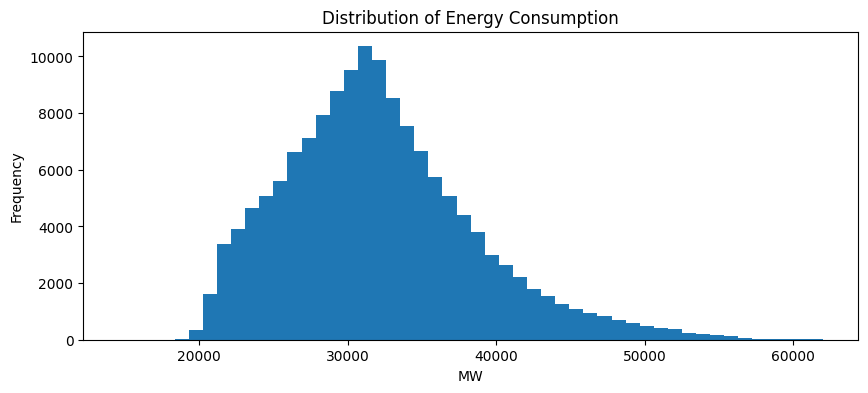

In [27]:
# Histogram of energy consumption
plt.figure(figsize=(10, 4))
plt.hist(df['PJME_MW'], bins=50)
plt.title('Distribution of Energy Consumption')
plt.xlabel('MW')
plt.ylabel('Frequency')
plt.show()

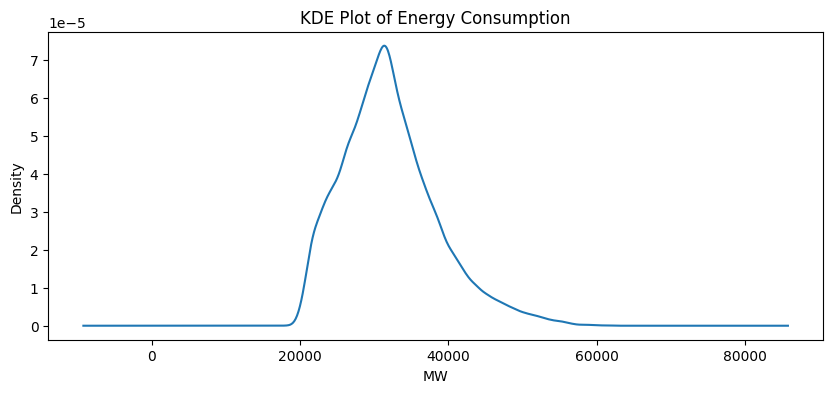

In [28]:
# KDE plot
plt.figure(figsize=(10, 4))
df['PJME_MW'].plot.kde()
plt.title('KDE Plot of Energy Consumption')
plt.xlabel('MW')
plt.show()

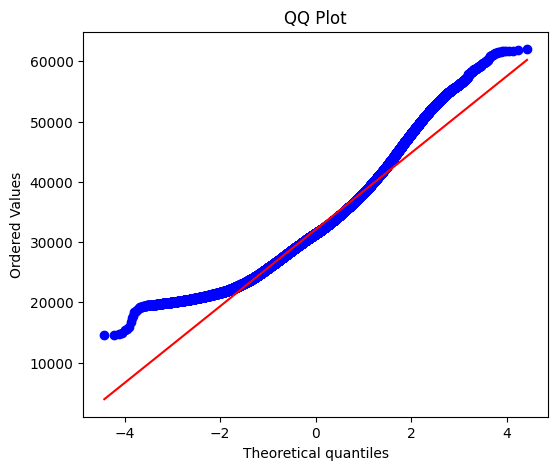

In [29]:
# QQ Plot
plt.figure(figsize=(6, 5))
stats.probplot(df['PJME_MW'], dist='norm', plot=plt)
plt.title('QQ Plot')
plt.show()

In [30]:
# Variability using std and IQR
print('Standard Deviation:', round(df['PJME_MW'].std(), 2))
Q1 = df['PJME_MW'].quantile(0.25)
Q3 = df['PJME_MW'].quantile(0.75)
print('IQR:', round(Q3 - Q1, 2))
print('Skewness:', round(df['PJME_MW'].skew(), 4))

Standard Deviation: 6464.01
IQR: 8077.0
Skewness: 0.739


## Step 9 - Rolling Statistics and Smoothing

In [31]:
# Compute 7-day rolling mean and rolling std (7 days = 24*7 hours)
df['rolling_mean'] = df['PJME_MW'].rolling(window=24*7, center=True).mean()
df['rolling_std']  = df['PJME_MW'].rolling(window=24*7, center=True).std()

print('Rolling statistics computed')
df[['PJME_MW', 'rolling_mean', 'rolling_std']].head(10)

Rolling statistics computed


,PJME_MW,rolling_mean,rolling_std
0,30393.0,NaN,NaN
1,29265.0,NaN,NaN
2,28357.0,NaN,NaN
3,27899.0,NaN,NaN
4,28057.0,NaN,NaN
5,28654.0,NaN,NaN
6,29308.0,NaN,NaN
7,29595.0,NaN,NaN
8,29943.0,NaN,NaN
9,30692.0,NaN,NaN


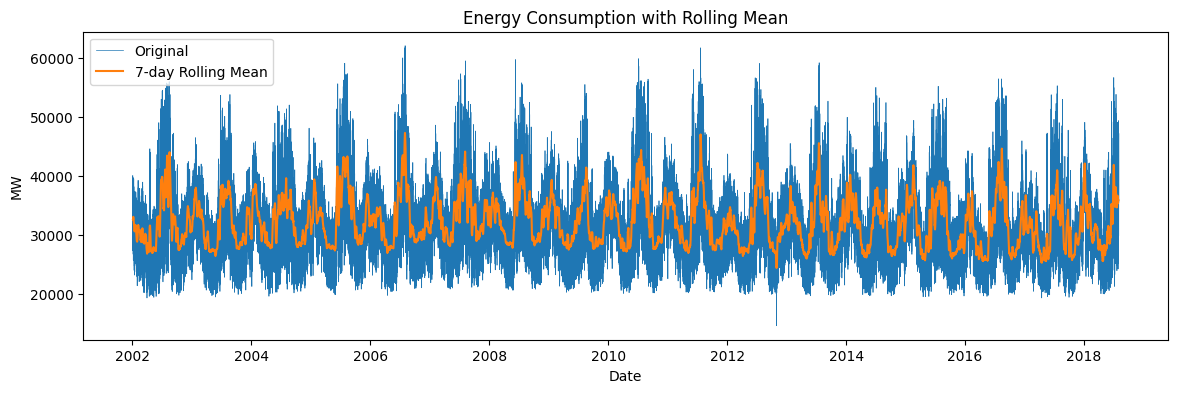

In [32]:
# Plot rolling mean
plt.figure(figsize=(14, 4))
plt.plot(df['Datetime'], df['PJME_MW'], label='Original', linewidth=0.5)
plt.plot(df['Datetime'], df['rolling_mean'], label='7-day Rolling Mean', linewidth=1.5)
plt.title('Energy Consumption with Rolling Mean')
plt.xlabel('Date')
plt.ylabel('MW')
plt.legend()
plt.show()

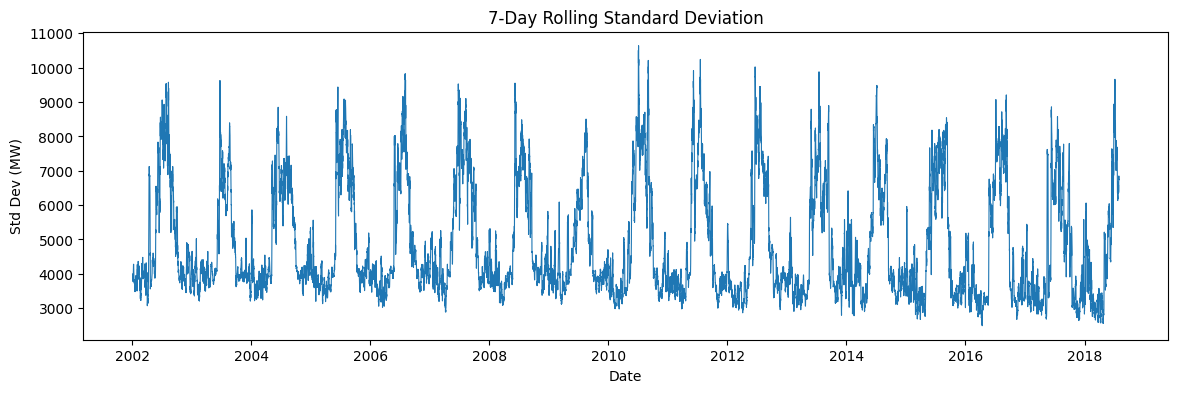

In [33]:
# Plot rolling std
plt.figure(figsize=(14, 4))
plt.plot(df['Datetime'], df['rolling_std'], linewidth=0.8)
plt.title('7-Day Rolling Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Std Dev (MW)')
plt.show()

## Step 10 - Lag Analysis and Autocorrelation

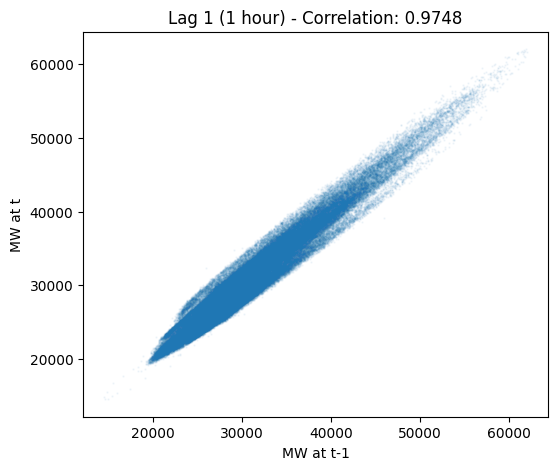

In [34]:
# Lag 1 hour - scatter plot
lag1 = df['PJME_MW'].shift(1)
plt.figure(figsize=(6, 5))
plt.scatter(lag1, df['PJME_MW'], alpha=0.05, s=0.5)
plt.title('Lag 1 (1 hour) - Correlation: ' + str(round(df['PJME_MW'].corr(lag1), 4)))
plt.xlabel('MW at t-1')
plt.ylabel('MW at t')
plt.show()

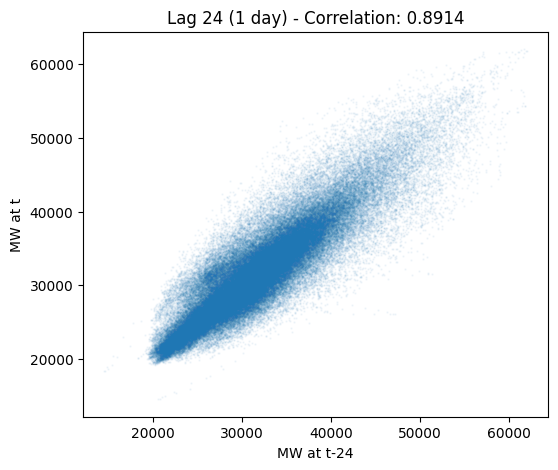

In [35]:
# Lag 24 hours - scatter plot
lag24 = df['PJME_MW'].shift(24)
plt.figure(figsize=(6, 5))
plt.scatter(lag24, df['PJME_MW'], alpha=0.05, s=0.5)
plt.title('Lag 24 (1 day) - Correlation: ' + str(round(df['PJME_MW'].corr(lag24), 4)))
plt.xlabel('MW at t-24')
plt.ylabel('MW at t')
plt.show()

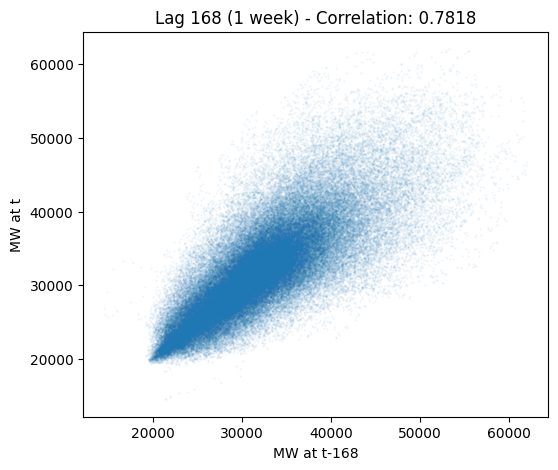

In [36]:
# Lag 168 hours - scatter plot (1 week)
lag168 = df['PJME_MW'].shift(168)
plt.figure(figsize=(6, 5))
plt.scatter(lag168, df['PJME_MW'], alpha=0.05, s=0.5)
plt.title('Lag 168 (1 week) - Correlation: ' + str(round(df['PJME_MW'].corr(lag168), 4)))
plt.xlabel('MW at t-168')
plt.ylabel('MW at t')
plt.show()

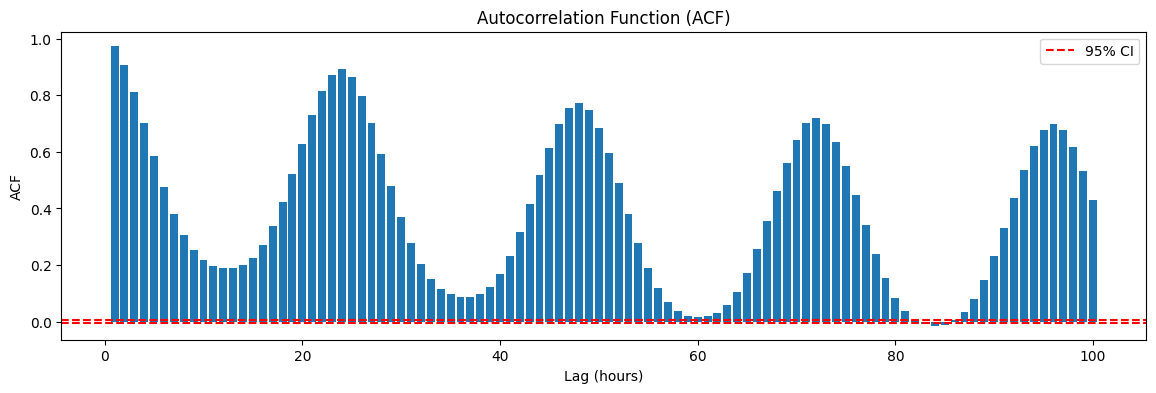

In [37]:
# Autocorrelation plot (ACF)
series = df['PJME_MW'].dropna()
max_lag = 100
acf_vals = [series.autocorr(lag=i) for i in range(1, max_lag + 1)]

plt.figure(figsize=(14, 4))
plt.bar(range(1, max_lag + 1), acf_vals)
plt.axhline(1.96 / np.sqrt(len(series)), color='red', linestyle='--', label='95% CI')
plt.axhline(-1.96 / np.sqrt(len(series)), color='red', linestyle='--')
plt.title('Autocorrelation Function (ACF)')
plt.xlabel('Lag (hours)')
plt.ylabel('ACF')
plt.legend()
plt.show()

## Step 11 - Trend Decomposition

In [38]:
# Resample to daily average for decomposition
daily = df.set_index('Datetime')['PJME_MW'].resample('D').mean().dropna()
print('Daily data shape:', daily.shape)

Daily data shape: (6059,)


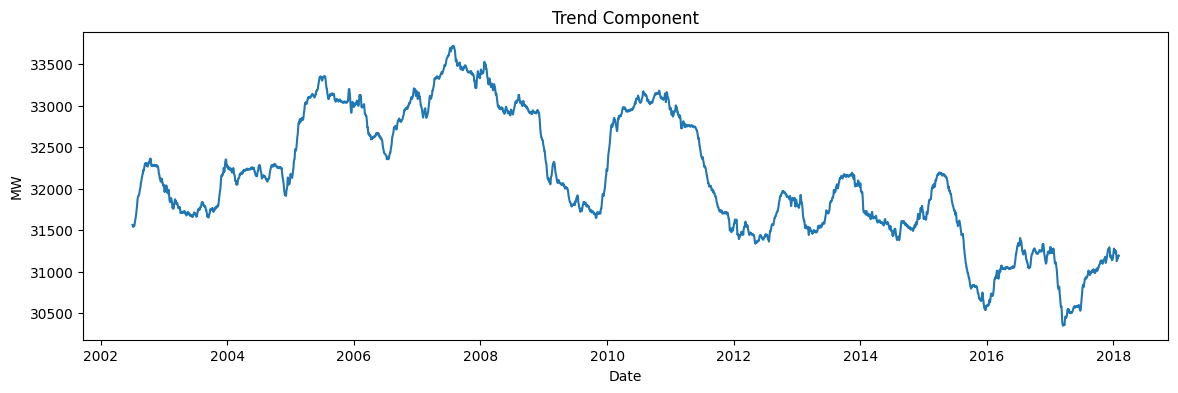

In [39]:
# Trend - using 365-day rolling mean
trend = daily.rolling(window=365, center=True).mean()

plt.figure(figsize=(14, 4))
plt.plot(daily.index, trend.values)
plt.title('Trend Component')
plt.xlabel('Date')
plt.ylabel('MW')
plt.show()

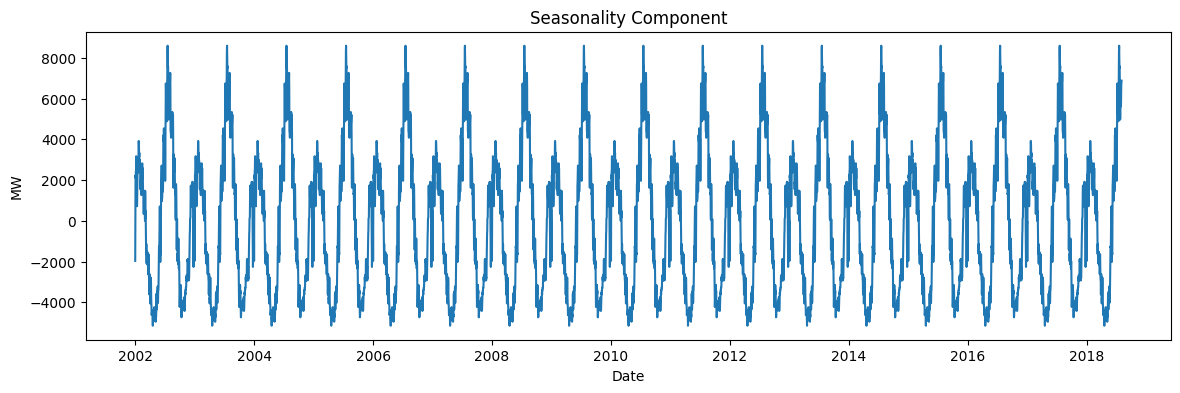

In [40]:
# Seasonality - detrended then averaged by day of year
detrended = daily - trend
detrended_df = detrended.to_frame('val')
detrended_df['doy'] = detrended_df.index.dayofyear
seasonal_map = detrended_df.groupby('doy')['val'].mean()
seasonality = detrended_df['doy'].map(seasonal_map)

plt.figure(figsize=(14, 4))
plt.plot(daily.index, seasonality.values)
plt.title('Seasonality Component')
plt.xlabel('Date')
plt.ylabel('MW')
plt.show()

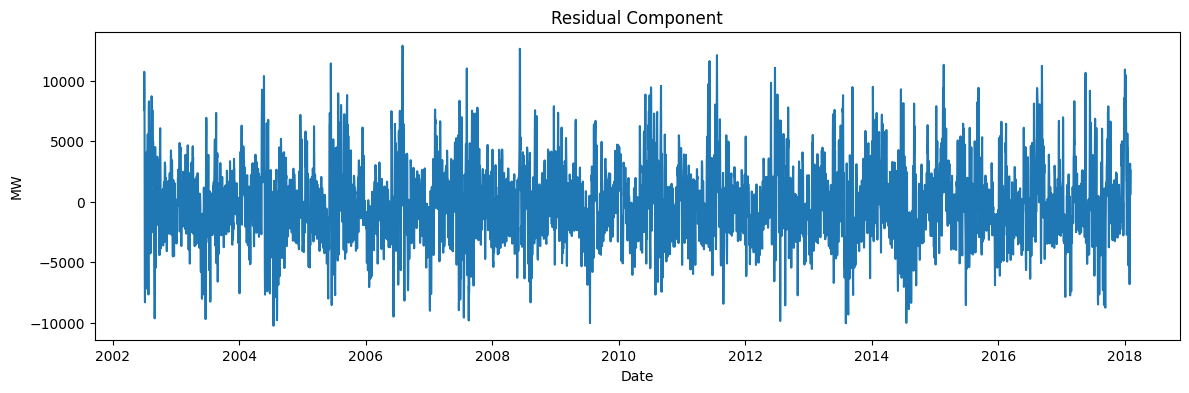

In [41]:
# Residual = Original - Trend - Seasonality
residual = daily.values - trend.values - seasonality.values

plt.figure(figsize=(14, 4))
plt.plot(daily.index, residual)
plt.title('Residual Component')
plt.xlabel('Date')
plt.ylabel('MW')
plt.show()

## Step 12 - Outlier Detection and Handling

In [42]:
# Statistics before outlier handling
print('Statistics BEFORE outlier handling:')
print(df['PJME_MW'].describe())

Statistics BEFORE outlier handling:
count    145366.000000
mean      32080.222831
std        6464.012166
min       14544.000000
25%       27573.000000
50%       31421.000000
75%       35650.000000
max       62009.000000
Name: PJME_MW, dtype: float64


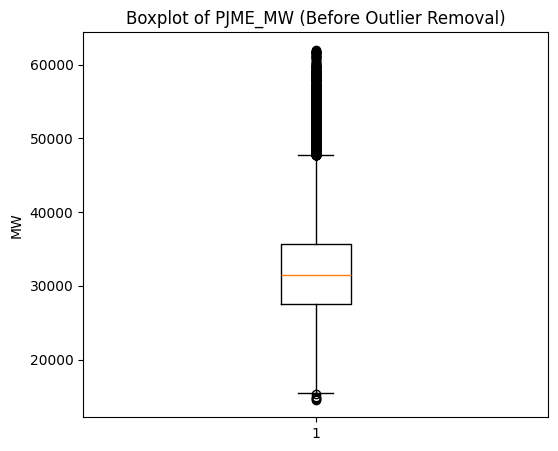

In [43]:
# Boxplot before outlier removal
plt.figure(figsize=(6, 5))
plt.boxplot(df['PJME_MW'].dropna())
plt.title('Boxplot of PJME_MW (Before Outlier Removal)')
plt.ylabel('MW')
plt.show()

In [5]:
# Step 1 - Find Q1 and Q3
Q1 = df['PJME_MW'].quantile(0.25)
Q3 = df['PJME_MW'].quantile(0.75)

print('Q1 (25th percentile):', round(Q1, 2))
print('Q3 (75th percentile):', round(Q3, 2))

Q1 (25th percentile): 27573.0
Q3 (75th percentile): 35650.0


In [6]:
# Step 2 - Calculate IQR
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('IQR:', round(IQR, 2))
print('Lower Bound:', round(lower_bound, 2))
print('Upper Bound:', round(upper_bound, 2))

IQR: 8077.0
Lower Bound: 15457.5
Upper Bound: 47765.5


In [46]:
# Step 3 - Count outliers
outliers = df[(df['PJME_MW'] < lower_bound) | (df['PJME_MW'] > upper_bound)]
print('Number of outliers found:', len(outliers))

Number of outliers found: 3455


In [7]:
# Step 4 - Remove outliers using IQR method
df_clean = df[(df['PJME_MW'] >= lower_bound) & (df['PJME_MW'] <= upper_bound)].copy()
df_clean.reset_index(drop=True, inplace=True)

print('Rows before:', len(df))
print('Rows after :', len(df_clean))
print('Rows removed:', len(df) - len(df_clean))

Rows before: 145366
Rows after : 141911
Rows removed: 3455


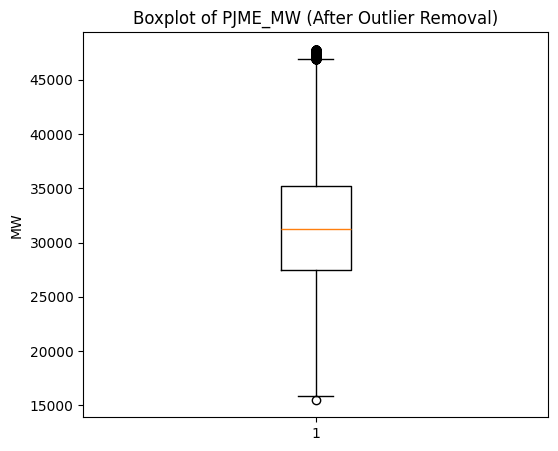

In [48]:
# Boxplot after outlier removal
plt.figure(figsize=(6, 5))
plt.boxplot(df_clean['PJME_MW'])
plt.title('Boxplot of PJME_MW (After Outlier Removal)')
plt.ylabel('MW')
plt.show()

In [49]:
# Statistics after outlier handling
print('Statistics AFTER outlier handling:')
print(df_clean['PJME_MW'].describe())

Statistics AFTER outlier handling:
count    141911.000000
mean      31616.354243
std        5789.464103
min       15526.000000
25%       27461.000000
50%       31266.000000
75%       35248.000000
max       47765.000000
Name: PJME_MW, dtype: float64


## Step 13 - Feature Engineering

In [8]:
# Re-extract time features on clean data
df_clean['hour']        = df_clean['Datetime'].dt.hour
df_clean['day']         = df_clean['Datetime'].dt.day
df_clean['month']       = df_clean['Datetime'].dt.month
df_clean['year']        = df_clean['Datetime'].dt.year
df_clean['day_of_week'] = df_clean['Datetime'].dt.dayofweek
df_clean['quarter']     = df_clean['Datetime'].dt.quarter

print('Time features added')

Time features added


In [9]:
# Cyclical encoding using sin and cos
# This helps the model understand that hour 23 is close to hour 0
df_clean['hour_sin']  = np.sin(2 * np.pi * df_clean['hour'] / 24)
df_clean['hour_cos']  = np.cos(2 * np.pi * df_clean['hour'] / 24)
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month'] / 12)
df_clean['dow_sin']   = np.sin(2 * np.pi * df_clean['day_of_week'] / 7)
df_clean['dow_cos']   = np.cos(2 * np.pi * df_clean['day_of_week'] / 7)

print('Cyclical features added')

Cyclical features added


In [10]:
# Binary features
df_clean['is_weekend']  = (df_clean['day_of_week'] >= 5).astype(int)
df_clean['is_summer']   = df_clean['month'].isin([6, 7, 8]).astype(int)
df_clean['is_winter']   = df_clean['month'].isin([12, 1, 2]).astype(int)
df_clean['is_peak_hour']= df_clean['hour'].isin(range(8, 21)).astype(int)

print('Binary features added')

Binary features added


In [11]:
# Lag features (from ACF analysis - lag 1, 24, 168 were most useful)
df_clean.sort_values('Datetime', inplace=True)
df_clean.reset_index(drop=True, inplace=True)

df_clean['lag_1']   = df_clean['PJME_MW'].shift(1)
df_clean['lag_24']  = df_clean['PJME_MW'].shift(24)
df_clean['lag_168'] = df_clean['PJME_MW'].shift(168)

print('Lag features added')

Lag features added


In [12]:
# Rolling mean features
df_clean['roll_mean_24']  = df_clean['PJME_MW'].rolling(24).mean().shift(1)
df_clean['roll_mean_168'] = df_clean['PJME_MW'].rolling(168).mean().shift(1)

# Drop rows with NaN (created by lag and rolling)
df_clean.dropna(inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print('Rolling features added')
print('Final dataset shape:', df_clean.shape)

Rolling features added
Final dataset shape: (141743, 23)


## Step 14 - Correlation and Feature Reduction

In [13]:
# Define feature columns
feature_cols = [
    'hour', 'day', 'month', 'year', 'day_of_week', 'quarter',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'is_summer', 'is_winter', 'is_peak_hour',
    'lag_1', 'lag_24', 'lag_168', 'roll_mean_24', 'roll_mean_168'
]

X = df_clean[feature_cols]
y = df_clean['PJME_MW']

print('Features:', feature_cols)
print('X shape:', X.shape)
print('y shape:', y.shape)

Features: ['hour', 'day', 'month', 'year', 'day_of_week', 'quarter', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_summer', 'is_winter', 'is_peak_hour', 'lag_1', 'lag_24', 'lag_168', 'roll_mean_24', 'roll_mean_168']
X shape: (141743, 21)
y shape: (141743,)


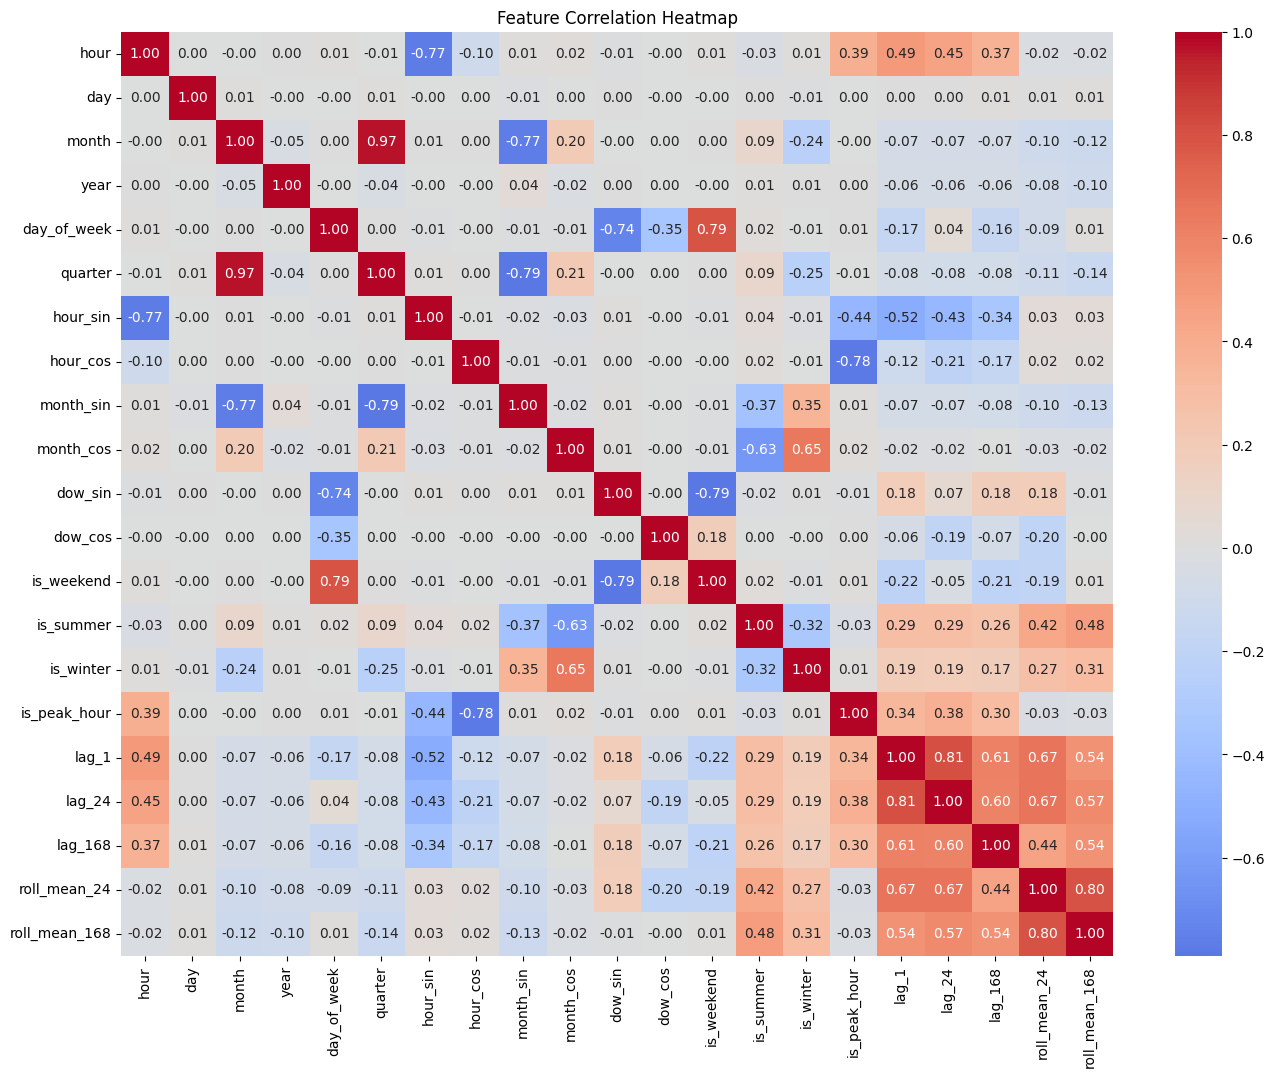

In [56]:
# Correlation heatmap of all features
plt.figure(figsize=(16, 12))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [14]:
# Remove features that are highly correlated with each other (|r| > 0.90)
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]

print('Dropping highly correlated features:', to_drop)
X = X.drop(columns=to_drop)
print('Remaining features:', list(X.columns))

Dropping highly correlated features: ['quarter']
Remaining features: ['hour', 'day', 'month', 'year', 'day_of_week', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_summer', 'is_winter', 'is_peak_hour', 'lag_1', 'lag_24', 'lag_168', 'roll_mean_24', 'roll_mean_168']


In [15]:
# Correlation of each feature with target variable
target_corr = X.corrwith(y).abs().sort_values(ascending=False)
print('Feature correlation with PJME_MW:')
print(target_corr)

Feature correlation with PJME_MW:
lag_1            0.968711
lag_24           0.819454
roll_mean_24     0.660105
lag_168          0.624733
roll_mean_168    0.534359
hour             0.494567
hour_sin         0.465468
is_peak_hour     0.434049
is_summer        0.292956
hour_cos         0.261456
is_weekend       0.218424
is_winter        0.189483
dow_sin          0.187647
day_of_week      0.176551
month_sin        0.070964
month            0.067847
year             0.057044
dow_cos          0.055523
month_cos        0.020048
day              0.003579
dtype: float64


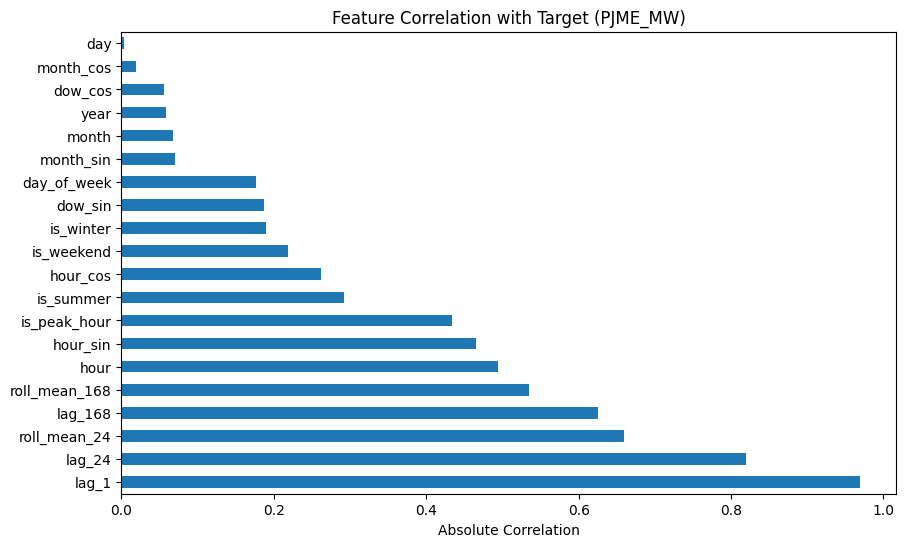

In [59]:
# Plot correlation with target
plt.figure(figsize=(10, 6))
target_corr.plot(kind='barh')
plt.title('Feature Correlation with Target (PJME_MW)')
plt.xlabel('Absolute Correlation')
plt.show()

In [16]:
# Keep only features with correlation > 0.05 with target
useful = target_corr[target_corr > 0.05].index.tolist()
X = X[useful]
print('Final features used for model:', useful)

Final features used for model: ['lag_1', 'lag_24', 'roll_mean_24', 'lag_168', 'roll_mean_168', 'hour', 'hour_sin', 'is_peak_hour', 'is_summer', 'hour_cos', 'is_weekend', 'is_winter', 'dow_sin', 'day_of_week', 'month_sin', 'month', 'year', 'dow_cos']


## Step 15 - Normality Test and Scaling

In [17]:
# Check skewness before scaling
skew_before = X.skew().sort_values(ascending=False)
print('Skewness BEFORE scaling:')
print(skew_before)

Skewness BEFORE scaling:
is_summer        1.235996
is_winter        1.135359
is_weekend       0.923962
lag_1            0.365322
lag_24           0.364944
lag_168          0.364771
roll_mean_24     0.258134
roll_mean_168    0.247766
month            0.041020
hour             0.035050
dow_sin          0.013461
year             0.004488
dow_cos         -0.000768
day_of_week     -0.012513
hour_cos        -0.014666
hour_sin        -0.036015
month_sin       -0.056648
is_peak_hour    -0.131068
dtype: float64


In [18]:
# Apply log1p to features with high skewness (|skew| > 1)
X_transformed = X.copy()
high_skew = skew_before[skew_before.abs() > 1].index.tolist()

for col in high_skew:
    if (X_transformed[col] >= 0).all():
        X_transformed[col] = np.log1p(X_transformed[col])
        print('log1p applied to:', col)

log1p applied to: is_summer
log1p applied to: is_winter


In [19]:
# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_transformed), columns=X_transformed.columns)

# Save scaler for demo
joblib.dump(scaler, 'scaler.pkl')
print('Scaler fitted and saved as scaler.pkl')

Scaler fitted and saved as scaler.pkl


In [64]:
# Check skewness after scaling
skew_after = X_scaled.skew().sort_values(ascending=False)
print('Skewness AFTER scaling:')
print(skew_after)

Skewness AFTER scaling:
is_summer        1.238763
is_winter        1.134501
is_weekend       0.923097
lag_1            0.365253
lag_24           0.365213
lag_168          0.364847
roll_mean_24     0.258825
roll_mean_168    0.249032
month            0.041534
hour             0.035118
dow_sin          0.014277
year             0.004581
dow_cos         -0.000775
day_of_week     -0.013125
hour_cos        -0.014641
hour_sin        -0.036109
month_sin       -0.057688
is_peak_hour    -0.131070
dtype: float64


## Step 16 - Model Training

In [20]:
# Split data into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 113394
Testing samples : 28349


In [21]:
# Model 1: Simple Linear Regression (using only top correlated feature)
top_feature = target_corr.index[0]
print('Top feature used:', top_feature)

slr = LinearRegression()
slr.fit(X_train[[top_feature]], y_train)

y_pred_slr = slr.predict(X_test[[top_feature]])

print('Simple Linear Regression Results:')
print('Train R2 :', round(r2_score(y_train, slr.predict(X_train[[top_feature]])), 4))
print('Test  R2 :', round(r2_score(y_test, y_pred_slr), 4))
print('MAE      :', round(mean_absolute_error(y_test, y_pred_slr), 2))
print('RMSE     :', round(np.sqrt(mean_squared_error(y_test, y_pred_slr)), 2))

Top feature used: lag_1
Simple Linear Regression Results:
Train R2 : 0.9385
Test  R2 : 0.9381
MAE      : 1106.4
RMSE     : 1446.1


In [22]:
# Model 2: Multiple Linear Regression (all features)
mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred_mlr = mlr.predict(X_test)

print('Multiple Linear Regression Results:')
print('Train R2 :', round(r2_score(y_train, mlr.predict(X_train)), 4))
print('Test  R2 :', round(r2_score(y_test, y_pred_mlr), 4))
print('MAE      :', round(mean_absolute_error(y_test, y_pred_mlr), 2))
print('RMSE     :', round(np.sqrt(mean_squared_error(y_test, y_pred_mlr)), 2))

# Save model
joblib.dump(mlr, 'mlr_model.pkl')
print('Model saved as mlr_model.pkl')

Multiple Linear Regression Results:
Train R2 : 0.9671
Test  R2 : 0.967
MAE      : 806.4
RMSE     : 1056.01
Model saved as mlr_model.pkl


In [23]:
# Model 3: Polynomial Regression (degree = 2)
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])
poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

print('Polynomial Regression (degree=2) Results:')
print('Train R2 :', round(r2_score(y_train, poly_model.predict(X_train)), 4))
print('Test  R2 :', round(r2_score(y_test, y_pred_poly), 4))
print('MAE      :', round(mean_absolute_error(y_test, y_pred_poly), 2))
print('RMSE     :', round(np.sqrt(mean_squared_error(y_test, y_pred_poly)), 2))

# Save model
joblib.dump(poly_model, 'poly_model.pkl')
print('Model saved as poly_model.pkl')

Polynomial Regression (degree=2) Results:
Train R2 : 0.9901
Test  R2 : 0.99
MAE      : 431.82
RMSE     : 581.9
Model saved as poly_model.pkl


In [24]:
# Model 4: Random Forest Regression
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print('Random Forest Regression Results:')
print('Train R2 :', round(r2_score(y_train, rf_model.predict(X_train)), 4))
print('Test  R2 :', round(r2_score(y_test, y_pred_rf), 4))
print('MAE      :', round(mean_absolute_error(y_test, y_pred_rf), 2))
print('RMSE     :', round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 2))

# Save model
joblib.dump(rf_model, 'rf_model.pkl')
print('Model saved as rf_model.pkl')

Random Forest Regression Results:
Train R2 : 0.9994
Test  R2 : 0.9958
MAE      : 258.79
RMSE     : 377.26
Model saved as rf_model.pkl


## Step 17 - Model Evaluation and Comparison

In [25]:
# Summary table of all models
results = pd.DataFrame({
    'Model': ['Simple LR', 'Multiple LR', 'Polynomial LR (deg=2)', 'Random Forest'],
    'Train R2': [
        round(r2_score(y_train, slr.predict(X_train[[top_feature]])), 4),
        round(r2_score(y_train, mlr.predict(X_train)), 4),
        round(r2_score(y_train, poly_model.predict(X_train)), 4),
        round(r2_score(y_train, rf_model.predict(X_train)), 4)
    ],
    'Test R2': [
        round(r2_score(y_test, y_pred_slr), 4),
        round(r2_score(y_test, y_pred_mlr), 4),
        round(r2_score(y_test, y_pred_poly), 4),
        round(r2_score(y_test, y_pred_rf), 4)
    ],
    'MAE': [
        round(mean_absolute_error(y_test, y_pred_slr), 2),
        round(mean_absolute_error(y_test, y_pred_mlr), 2),
        round(mean_absolute_error(y_test, y_pred_poly), 2),
        round(mean_absolute_error(y_test, y_pred_rf), 2)
    ],
    'RMSE': [
        round(np.sqrt(mean_squared_error(y_test, y_pred_slr)), 2),
        round(np.sqrt(mean_squared_error(y_test, y_pred_mlr)), 2),
        round(np.sqrt(mean_squared_error(y_test, y_pred_poly)), 2),
        round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 2)
    ]
})

print(results.to_string(index=False))

                Model  Train R2  Test R2     MAE    RMSE
            Simple LR    0.9385   0.9381 1106.40 1446.10
          Multiple LR    0.9671   0.9670  806.40 1056.01
Polynomial LR (deg=2)    0.9901   0.9900  431.82  581.90
        Random Forest    0.9994   0.9958  258.79  377.26


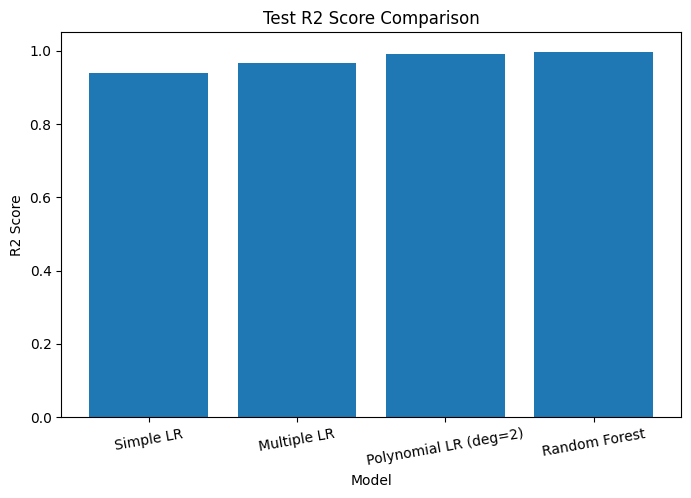

In [30]:
# Bar chart comparing Test R2 of all models
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['Test R2'])
plt.title('Test R2 Score Comparison')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=10)
plt.show()

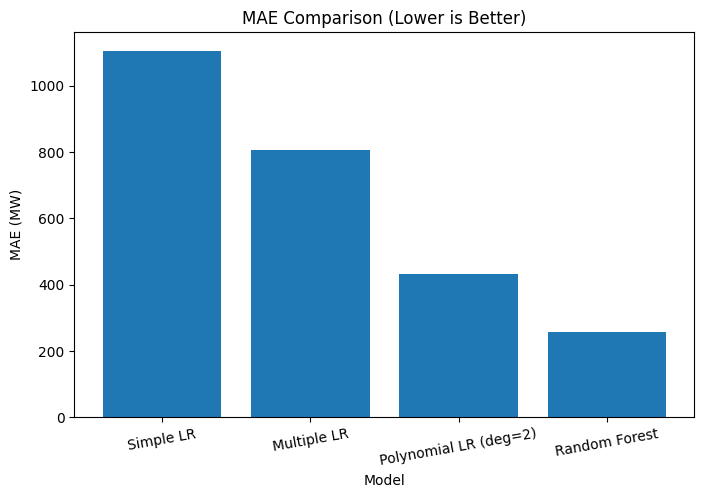

In [31]:
# Bar chart comparing MAE of all models
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['MAE'])
plt.title('MAE Comparison (Lower is Better)')
plt.xlabel('Model')
plt.ylabel('MAE (MW)')
plt.xticks(rotation=10)
plt.show()

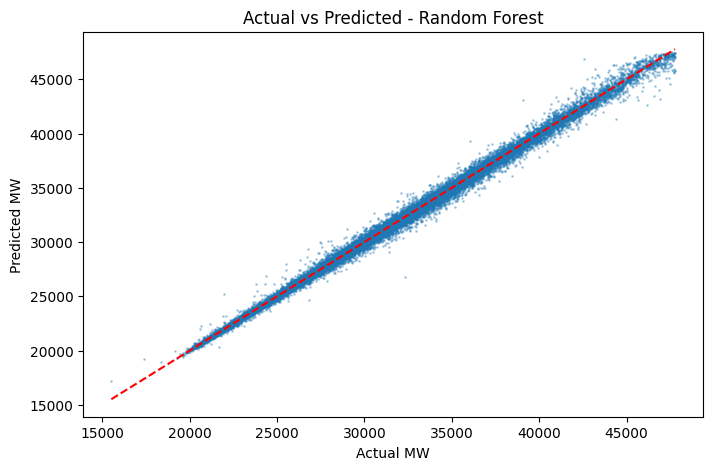

In [32]:
# Actual vs Predicted plot for best model
prediction_map = {
    'Simple LR': y_pred_slr,
    'Multiple LR': y_pred_mlr,
    'Polynomial LR (deg=2)': y_pred_poly,
    'Random Forest': y_pred_rf
}
best_model_name = results.loc[results['Test R2'].idxmax(), 'Model']
best_predictions = prediction_map[best_model_name]

plt.figure(figsize=(8, 5))
plt.scatter(y_test, best_predictions, alpha=0.3, s=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Actual vs Predicted - {best_model_name}')
plt.xlabel('Actual MW')
plt.ylabel('Predicted MW')
plt.show()

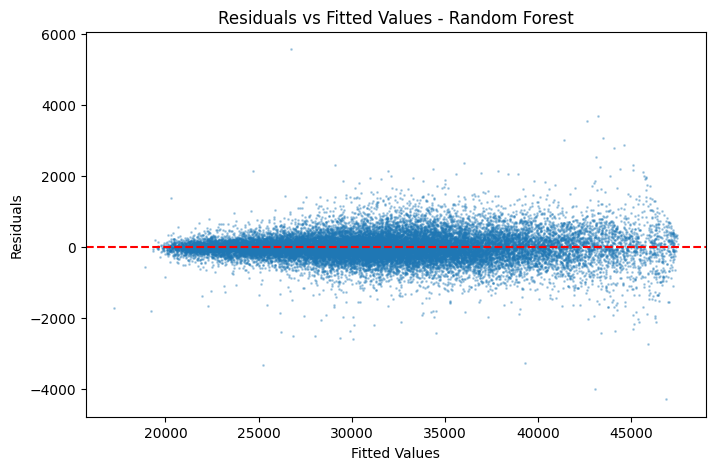

In [33]:
# Residual plot for best model
residuals = y_test.values - best_predictions

plt.figure(figsize=(8, 5))
plt.scatter(best_predictions, residuals, alpha=0.3, s=1)
plt.axhline(0, color='red', linestyle='--')
plt.title(f'Residuals vs Fitted Values - {best_model_name}')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

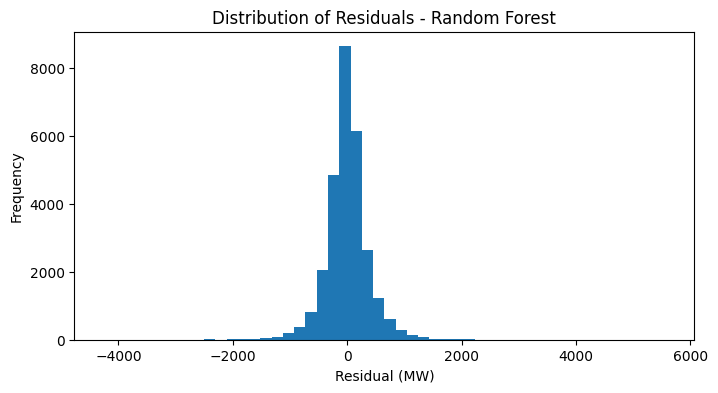

In [34]:
# Distribution of residuals for best model
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50)
plt.title(f'Distribution of Residuals - {best_model_name}')
plt.xlabel('Residual (MW)')
plt.ylabel('Frequency')
plt.show()

In [35]:
# Final best model summary
best_idx = results['Test R2'].idxmax()
best = results.loc[best_idx]

print('========== BEST MODEL ==========')
print('Model  :', best['Model'])
print('Test R2:', best['Test R2'])
print('MAE    :', best['MAE'], 'MW')
print('RMSE   :', best['RMSE'], 'MW')

========== BEST MODEL ==========
Model  : Random Forest
Test R2: 0.9958
MAE    : 258.79 MW
RMSE   : 377.26 MW
